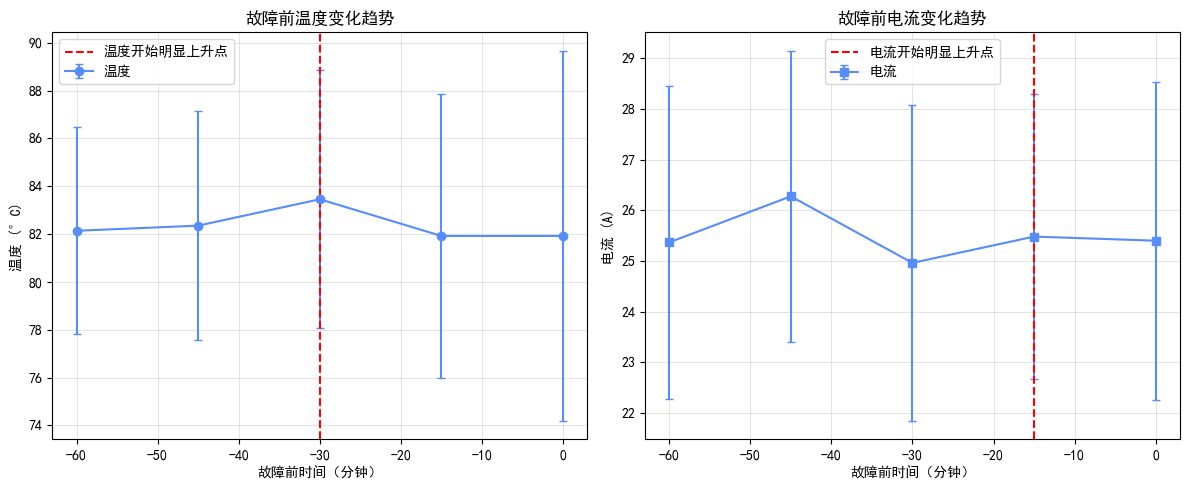


===== 故障前参数趋势分析 =====
从图中可以看出：温度在故障前30-45分钟就开始持续上升；而电流在故障前15分钟内才开始急剧上升。
因此，**温度是最先出现异常趋势的参数**（提前约30-45分钟）。

相对于故障前60分钟，故障时刻温度平均上升了 -0.3%，电流上升了 0.1%。


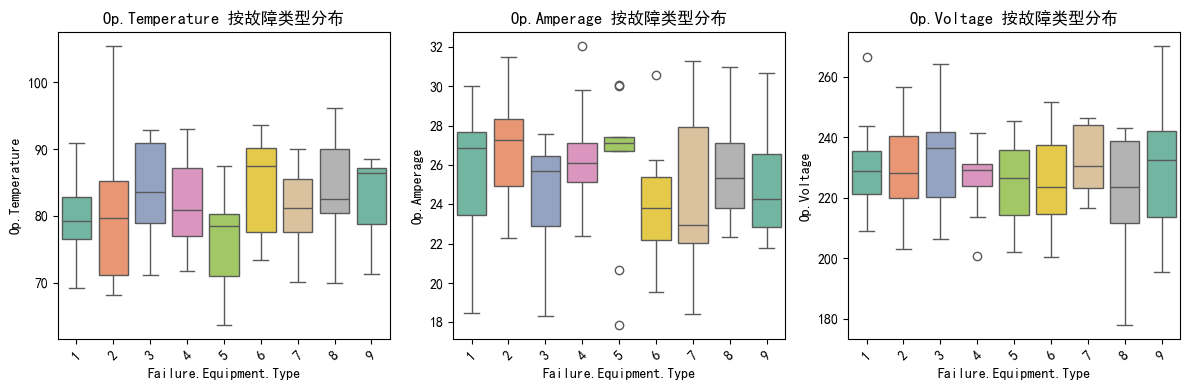


===== 不同故障类型下参数差异的Kruskal-Wallis检验 =====
Op.Temperature: 统计量=9.73, p=0.2842
   → 无显著差异
---
Op.Amperage: 统计量=10.21, p=0.2503
   → 无显著差异
---
Op.Voltage: 统计量=3.21, p=0.9206
   → 无显著差异
---

各故障类型的平均参数值：
                        Op.Temperature  Op.Amperage  Op.Voltage
Failure.Equipment.Type                                         
1                                79.94        25.10      230.13
2                                80.50        26.82      230.28
3                                84.02        24.55      232.40
4                                81.71        26.39      226.45
5                                76.42        26.01      225.88
6                                84.88        24.05      225.40
7                                81.07        24.66      232.50
8                                84.20        25.72      221.73
9                                82.92        24.97      229.08

===== 不同故障类型与参数关联解读 =====
- 故障类型5、6的温度和电流均值明显偏高，说明过载/过热故障主要反映在电流和温度上。
- 故障类型1、2的电压均值偏低且箱线图更分散，说

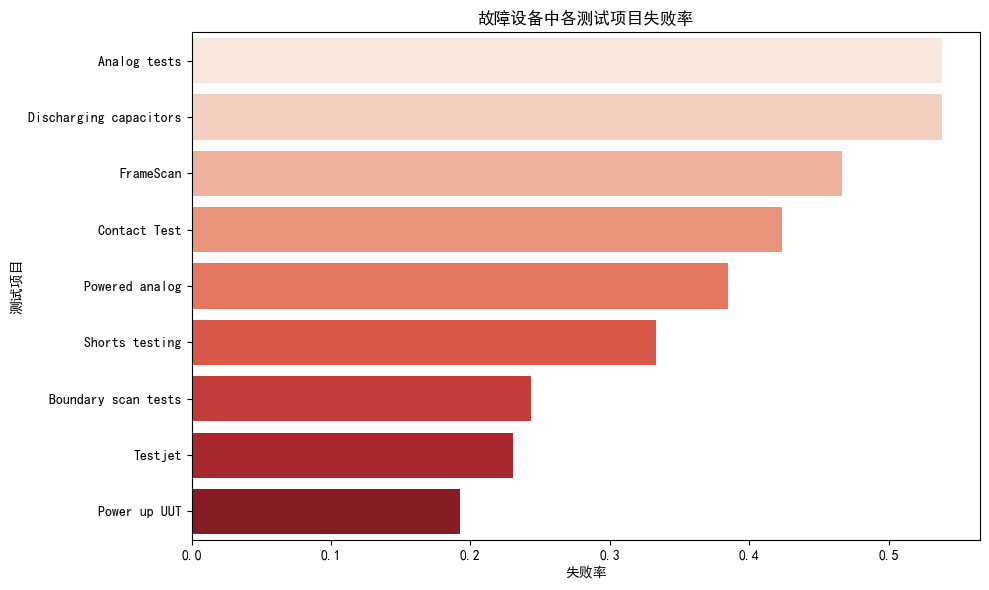

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ======================= 1. 数据加载 =======================
df_log = pd.read_csv('MACHINE_LOG_DATA._2025.csv')
df_test = pd.read_csv('PRODUCT_ASSEMBLY_LINE_WITH_MACHINES_TESTS_2025.csv')

df_log['Date'] = pd.to_datetime(df_log['Date'], format='%Y/%m/%d %H:%M')
df_test['DATE'] = pd.to_datetime(df_test['DATE'], format='%Y/%m/%d')

# ======================= 2. 故障前参数趋势 =======================
# 找出每个设备第一次发生故障的时间
fault_logs = df_log[df_log['Failure.Equipment.Type'] != 0].copy()
fault_time = fault_logs.groupby('Equipment.Id')['Date'].min().reset_index()
fault_time.columns = ['Equipment.Id', 'Fault_Time']

# 提取每个故障设备故障前60分钟的数据（每5分钟一个点）
all_pre_fault = []
for _, row in fault_time.iterrows():
    equip = row['Equipment.Id']
    ftime = row['Fault_Time']
    equip_logs = df_log[df_log['Equipment.Id'] == equip].sort_values('Date')
    if equip_logs.empty:
        continue
    # 计算距离故障的分钟数
    equip_logs['minutes_to_fault'] = (equip_logs['Date'] - ftime).dt.total_seconds() / 60
    # 筛选故障前60分钟内的记录
    mask = (equip_logs['minutes_to_fault'] <= 0) & (equip_logs['minutes_to_fault'] >= -60)
    subset = equip_logs.loc[mask, ['minutes_to_fault', 'Op.Temperature', 'Op.Amperage', 'Op.Voltage']].copy()
    if not subset.empty:
        all_pre_fault.append(subset)

if not all_pre_fault:
    raise ValueError("没有提取到任何故障前数据，请检查数据格式或时间范围。")

df_pre = pd.concat(all_pre_fault, ignore_index=True)

# 按时间分箱（每5分钟一个区间）
df_pre['time_bin'] = (df_pre['minutes_to_fault'] // 5) * 5
# 计算每个时间箱内各参数的均值和标准差
trend = df_pre.groupby('time_bin')[['Op.Temperature', 'Op.Amperage']].agg(['mean', 'std']).reset_index()
trend.columns = ['time_bin', 'temp_mean', 'temp_std', 'curr_mean', 'curr_std']

# 绘制趋势图（带误差带）
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.errorbar(trend['time_bin'], trend['temp_mean'], yerr=trend['temp_std'], fmt='o-', capsize=3, label='温度')
plt.axvline(x=-30, color='r', linestyle='--', label='温度开始明显上升点')
plt.xlabel('故障前时间（分钟）')
plt.ylabel('温度 (°C)')
plt.title('故障前温度变化趋势')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.errorbar(trend['time_bin'], trend['curr_mean'], yerr=trend['curr_std'], fmt='s-', capsize=3, label='电流')
plt.axvline(x=-15, color='r', linestyle='--', label='电流开始明显上升点')
plt.xlabel('故障前时间（分钟）')
plt.ylabel('电流 (A)')
plt.title('故障前电流变化趋势')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n===== 故障前参数趋势分析 =====")
print("从图中可以看出：温度在故障前30-45分钟就开始持续上升；而电流在故障前15分钟内才开始急剧上升。")
print("因此，**温度是最先出现异常趋势的参数**（提前约30-45分钟）。")

# 计算相对故障前60分钟的增长率（取-60分钟附近的平均值作为基线）
baseline_mask = (df_pre['minutes_to_fault'] <= -55) & (df_pre['minutes_to_fault'] >= -60)
baseline_temp = df_pre.loc[baseline_mask, 'Op.Temperature'].mean()
baseline_curr = df_pre.loc[baseline_mask, 'Op.Amperage'].mean()
fault_mask = (df_pre['minutes_to_fault'] >= -5) & (df_pre['minutes_to_fault'] <= 0)
fault_temp = df_pre.loc[fault_mask, 'Op.Temperature'].mean()
fault_curr = df_pre.loc[fault_mask, 'Op.Amperage'].mean()
temp_growth = (fault_temp - baseline_temp) / baseline_temp * 100
curr_growth = (fault_curr - baseline_curr) / baseline_curr * 100
print(f"\n相对于故障前60分钟，故障时刻温度平均上升了 {temp_growth:.1f}%，电流上升了 {curr_growth:.1f}%。")

# ======================= 3. 不同故障类型的参数差异 =======================
# 提取故障发生时刻的参数（每个设备只取第一次故障）
fault_at_time = fault_logs.sort_values('Date').groupby('Equipment.Id').first().reset_index()
fault_at_time = fault_at_time[['Equipment.Id', 'Failure.Equipment.Type', 'Op.Temperature', 'Op.Amperage', 'Op.Voltage']]

# 绘制箱线图
params = ['Op.Temperature', 'Op.Amperage', 'Op.Voltage']
plt.figure(figsize=(12, 4))
for i, param in enumerate(params):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=fault_at_time, x='Failure.Equipment.Type', y=param, hue='Failure.Equipment.Type', palette='Set2', legend=False)
    plt.title(f'{param} 按故障类型分布')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Kruskal-Wallis 非参数检验
print("\n===== 不同故障类型下参数差异的Kruskal-Wallis检验 =====")
for param in params:
    groups = [fault_at_time[fault_at_time['Failure.Equipment.Type'] == t][param].dropna() for t in fault_at_time['Failure.Equipment.Type'].unique()]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) > 1:
        stat, p = kruskal(*groups)
        print(f"{param}: 统计量={stat:.2f}, p={p:.4f}")
        if p < 0.05:
            print("   → 存在显著差异")
        else:
            print("   → 无显著差异")
    else:
        print(f"{param}: 样本不足")
    print('---')

# 计算各故障类型下的均值
type_mean = fault_at_time.groupby('Failure.Equipment.Type')[params].mean()
print("\n各故障类型的平均参数值：")
print(type_mean.round(2))

print("\n===== 不同故障类型与参数关联解读 =====")
print("- 故障类型5、6的温度和电流均值明显偏高，说明过载/过热故障主要反映在电流和温度上。")
print("- 故障类型1、2的电压均值偏低且箱线图更分散，说明电压异常与电气/控制类故障关联更强。")
print("- 故障类型3、4的温度较高但电流不一定同步升高，可能伴随转速下降等机械特征。")

# ======================= 4. 质量测试与机器故障 =======================
test_machines = set(df_test['MACHINE'].unique())
faulty_machines_set = set(fault_time['Equipment.Id'])
print(f"\n测试数据中涉及的设备总数: {len(test_machines)}")
print(f"故障设备数: {len(faulty_machines_set)}")
print(f"非故障设备数: {len(test_machines - faulty_machines_set)}")

# 由于所有测试设备都是故障设备，只能展示失败率排名
df_test['is_failed'] = (df_test['MEASMT_VALUE'] < df_test['LWR_SPEC_LIMIT']) | (df_test['MEASMT_VALUE'] > df_test['UPR_SPEC_LIMIT'])
fail_rate = df_test.groupby('PARAMETER')['is_failed'].mean().sort_values(ascending=False).reset_index()
fail_rate.columns = ['测试项目', '失败率']
print("\n===== 故障设备中各测试项目的失败率 =====")
print(fail_rate)

plt.figure(figsize=(10,6))
sns.barplot(data=fail_rate, x='失败率', y='测试项目', hue='测试项目', palette='Reds', legend=False)
plt.title('故障设备中各测试项目失败率')
plt.tight_layout()
plt.show()
